Device: cuda
PyTorch version: 2.5.1
✓ Dataset loaded from: ransom.csv
Shape: (21752, 77)

Column names:
['md5', 'sha1', 'file_extension', 'EntryPoint', 'PEType', 'MachineType', 'magic_number', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'oem_identifier', 'address_of_ne_header', 'Magic', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'OperatingSystemVersion', 'ImageVersion', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'Subsystem', 'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'text_PointerToRelocations', 'text_PointerToLineNumbers', 'text_Characte

d:\Anaconda\envs\tweet_project\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [4] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
d:\Anaconda\envs\tweet_project\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Class imbalance ratio (neg/pos): 0.9999
pos_weight for BCE loss: 0.9999

MANet ready — Input dim: 18 | Trainable params: 574,081
MANet(
  (embedding): Sequential(
    (0): Linear(in_features=18, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
  )
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (ffn): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
  )
  (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, i

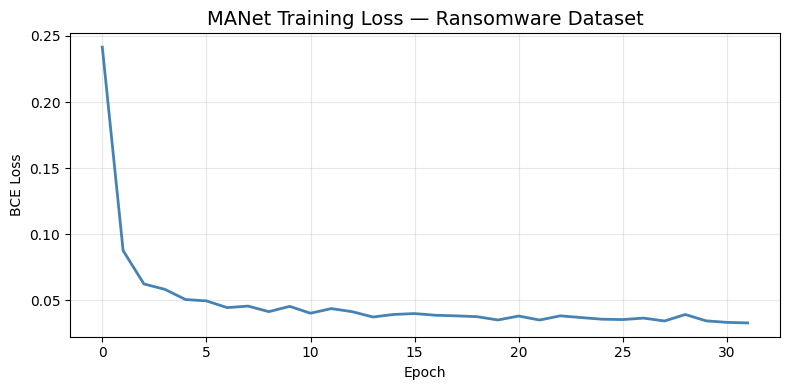


Training Random Forest baseline...
Random Forest done.
Training LightGBM baseline...


d:\Anaconda\envs\tweet_project\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\tweet_project\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM done.

TABLE 1 — Performance Comparison (Ransomware Dataset)
                  Accuracy  Precision  Recall  F1-Score  Brier Score  AUC-ROC
Model                                                                        
Random Forest       0.9931     0.9891  0.9972    0.9931       0.0057   0.9990
LightGBM            0.9940     0.9909  0.9972    0.9940       0.0053   0.9991
MANet (Proposed)    0.9876     0.9796  0.9959    0.9877       0.0118   0.9964

TABLE 2 — Threshold Optimization (τ* = 0.1542)
               Threshold  Precision  Recall      F1  False Positives
Strategy                                                            
Default (0.5)     0.5000     0.9796  0.9959  0.9877               45
Strict Recall     0.0001     0.5685  1.0000  0.7249             1651
F2-Optimized      0.1542     0.9766  0.9972  0.9868               52


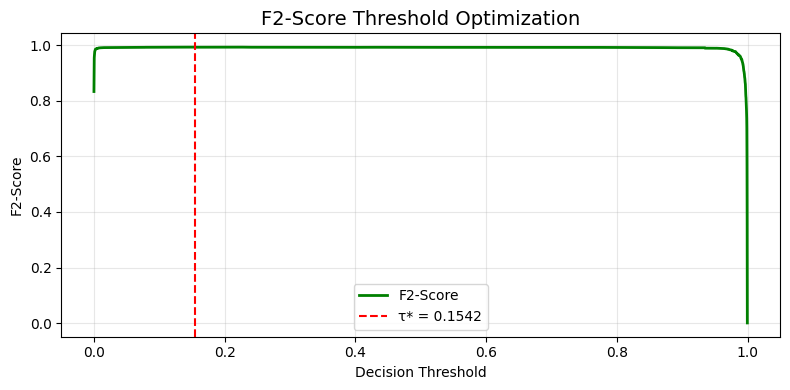

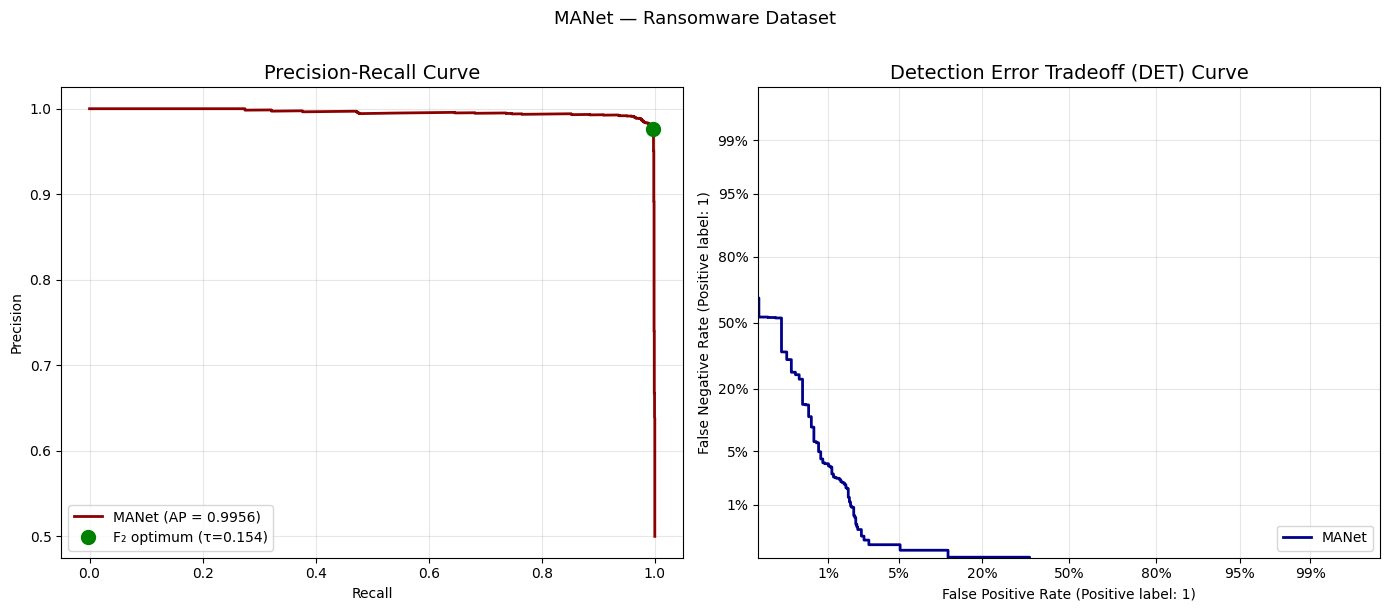

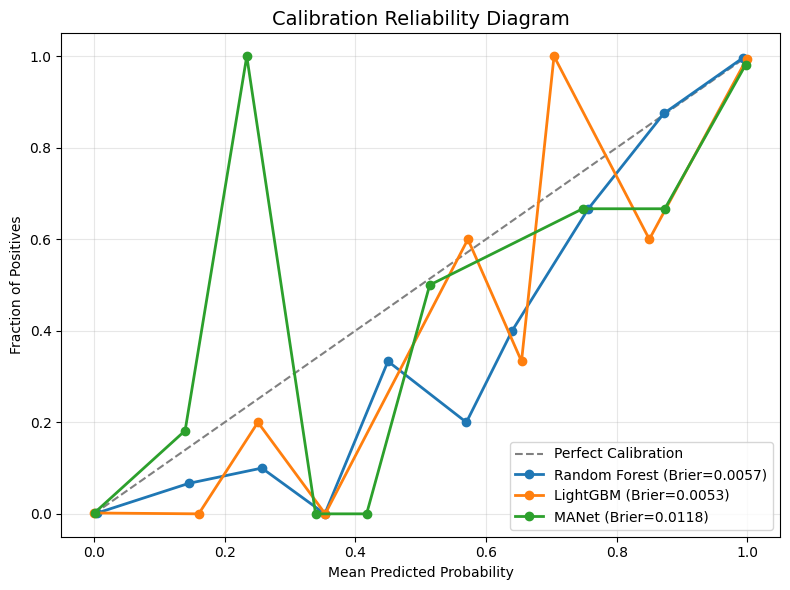

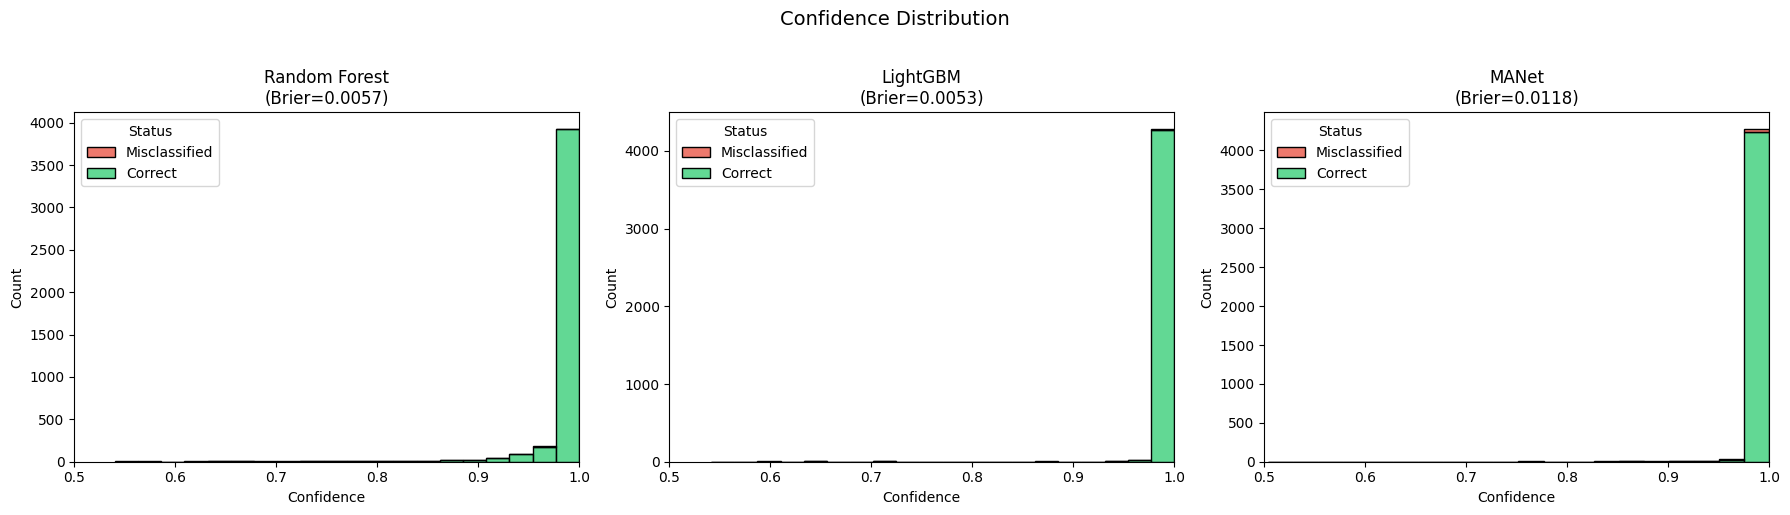


Extracting MANet embeddings for t-SNE...
Computing t-SNE on 1000 samples...
  - Raw features...
  - MANet embeddings...


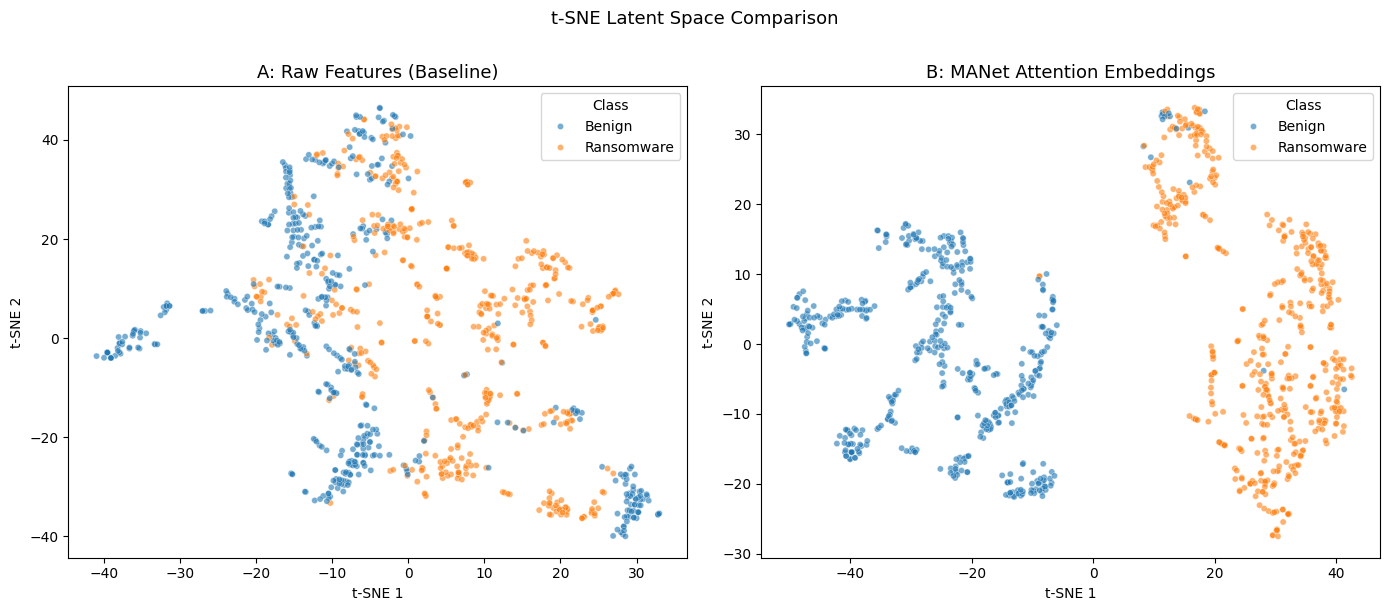

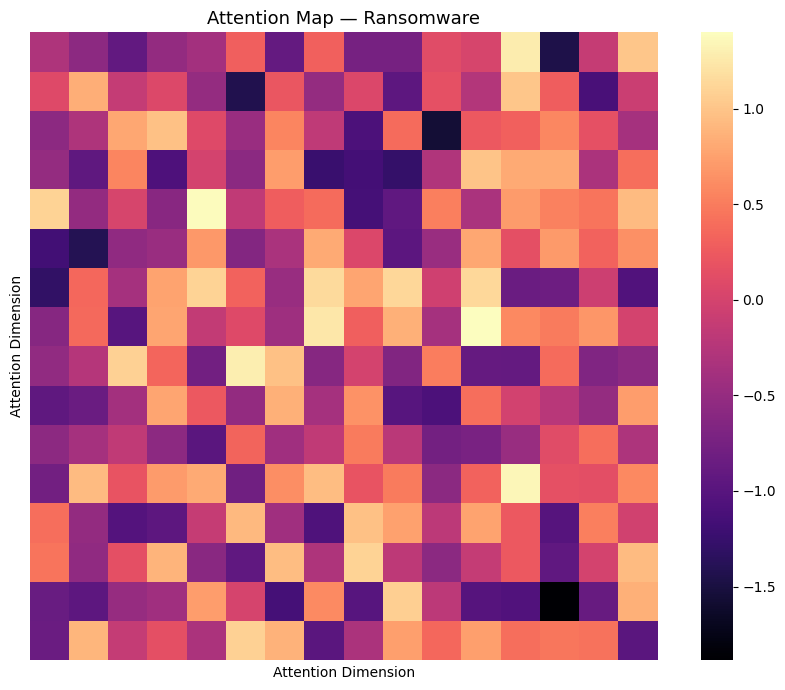

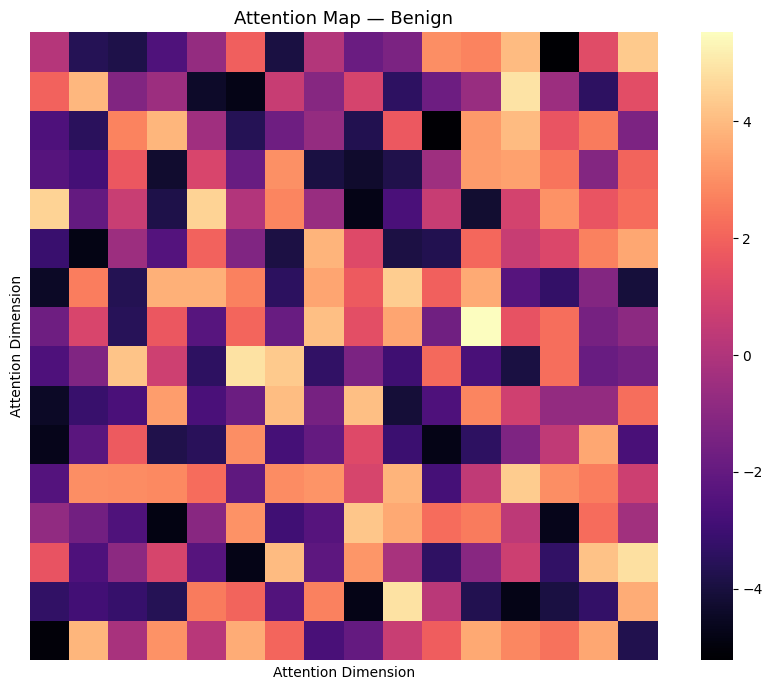

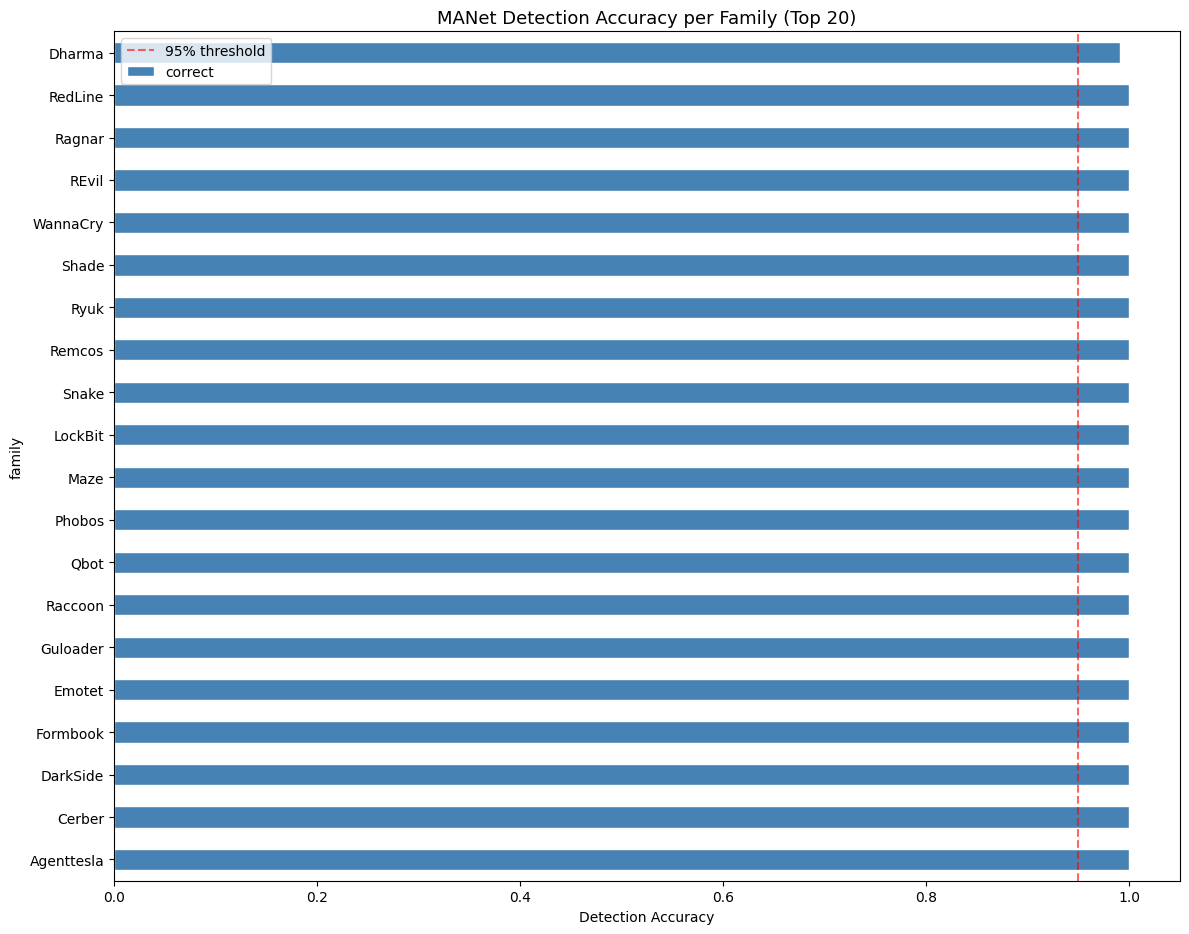


=== Per-Family Performance (Top 10) ===
family
Agenttesla    1.0
Cerber        1.0
DarkSide      1.0
Formbook      1.0
Emotet        1.0
Guloader      1.0
Raccoon       1.0
Qbot          1.0
Phobos        1.0
Maze          1.0

=== Families Needing Improvement (Bottom 5) ===
family
Glupteba    0.984127
NanoCore    0.983471
Ursnif      0.983333
Benign      0.979320
njRat       0.978947

✓ All results saved to 'paper_figures/' directory
  - performance_metrics.csv
  - threshold_analysis.csv
  - predictions.csv
  - All figures (PDF format)

FINAL RESULTS SUMMARY — RANSOMWARE DATASET

Dataset Statistics:
  - Total samples: 21752
  - Training samples: 17401
  - Test samples: 4351
  - Features used: 18
  - Class imbalance (neg/pos): 1.00:1

Performance Metrics:
                  Accuracy  Precision  Recall  F1-Score  Brier Score  AUC-ROC
Model                                                                        
Random Forest       0.9931     0.9891  0.9972    0.9931       0.0057   0.9990

In [2]:
# =============================================================================
# MANet — Cross-Dataset Validation on Ransomware Dataset 2024 (LOCAL VERSION)
# Dataset: ransomware_dataset.csv (downloaded from Kaggle)
# 
# Run this code on your local machine with the dataset in the same directory
# or update the DATASET_PATH variable to point to your file location
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install dependencies (run once in your local environment)
# ─────────────────────────────────────────────────────────────────────────────
# !pip install torch pandas numpy scikit-learn matplotlib seaborn lightgbm


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    f1_score, accuracy_score,
    precision_score, recall_score,
    brier_score_loss, roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    DetCurveDisplay,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# Create output directory
os.makedirs('paper_figures', exist_ok=True)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Load Dataset (Update this path to your local file location)
# ─────────────────────────────────────────────────────────────────────────────

# ========== UPDATE THIS PATH ==========
# Option 1: If the CSV is in the same directory as this script
DATASET_PATH = 'ransom.csv'  # Change to your actual filename

# Option 2: If it's in a different folder, use full path
# DATASET_PATH = 'C:/Users/YourName/Downloads/ransomware_dataset.csv'  # Windows
# DATASET_PATH = '/home/username/Downloads/ransomware_dataset.csv'     # Linux/Mac

# Option 3: If the filename is different (e.g., 'ransom.csv')
# DATASET_PATH = 'ransom.csv'

# Check if file exists
if not os.path.exists(DATASET_PATH):
    print(f"❌ File not found at: {DATASET_PATH}")
    print("\nPlease update DATASET_PATH with the correct location of your CSV file.")
    print("\nCurrent working directory:", os.getcwd())
    print("\nFiles in current directory:")
    for f in os.listdir('.'):
        if f.endswith('.csv'):
            print(f"  - {f}")
    raise FileNotFoundError(f"Cannot find dataset at {DATASET_PATH}")

# Load the dataset
df = pd.read_csv(DATASET_PATH)
print(f"✓ Dataset loaded from: {DATASET_PATH}")
print(f"Shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Data Inspection & Column Mapping
# ─────────────────────────────────────────────────────────────────────────────

# Identify label column (try common names)
label_candidates = ['label', 'Label', 'class', 'Class', 'target', 'Target', 'malware', 'Malware']
LABEL_COL = None
for col in label_candidates:
    if col in df.columns:
        LABEL_COL = col
        break

if LABEL_COL is None:
    # If no standard name, look for binary column
    for col in df.columns:
        if df[col].nunique() == 2:
            LABEL_COL = col
            break

if LABEL_COL is None:
    raise ValueError("Could not identify label column. Please check column names.")

# Identify family column (optional)
family_candidates = ['family', 'Family', 'malware_family', 'type', 'Type', 'malware_type']
FAMILY_COL = None
for col in family_candidates:
    if col in df.columns:
        FAMILY_COL = col
        break

# Identify timestamp column (optional)
timestamp_candidates = ['timestamp', 'Timestamp', 'time', 'Time', 'date', 'Date']
TIMESTAMP_COL = None
for col in timestamp_candidates:
    if col in df.columns:
        TIMESTAMP_COL = col
        break

print(f"\nUsing label column: '{LABEL_COL}'")
if FAMILY_COL:
    print(f"Using family column: '{FAMILY_COL}'")
if TIMESTAMP_COL:
    print(f"Using timestamp column: '{TIMESTAMP_COL}'")

# Print label distribution
print("\nLabel distribution:")
label_counts = df[LABEL_COL].value_counts()
print(label_counts)

# Map labels to 0/1 if needed
unique_labels = df[LABEL_COL].unique()
if len(unique_labels) == 2:
    if set(unique_labels) != {0, 1}:
        label_map = {unique_labels[0]: 0, unique_labels[1]: 1}
        df[LABEL_COL] = df[LABEL_COL].map(label_map)
        print(f"Mapped labels: {unique_labels[0]}→0, {unique_labels[1]}→1")

if FAMILY_COL:
    print(f"\nMalware families ({df[FAMILY_COL].nunique()} unique):")
    print(df[FAMILY_COL].value_counts().head(20))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Data Preprocessing & Train/Test Split
# ─────────────────────────────────────────────────────────────────────────────

# Drop non-feature columns
DROP_COLS = [LABEL_COL]
if FAMILY_COL:
    DROP_COLS.append(FAMILY_COL)
if TIMESTAMP_COL:
    DROP_COLS.append(TIMESTAMP_COL)

# Drop any non-numeric columns
non_numeric_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
extra_drop = [c for c in non_numeric_cols if c not in DROP_COLS]
if extra_drop:
    print(f"\nDropping non-numeric columns: {extra_drop[:10]}")  # Show first 10
    if len(extra_drop) > 10:
        print(f"  ... and {len(extra_drop) - 10} more")
    DROP_COLS.extend(extra_drop)

# Prepare features and labels
y_all = df[LABEL_COL].values.astype(np.float32)
X_all = df.drop(columns=DROP_COLS, errors='ignore').values.astype(np.float32)

print(f"\nFull dataset: {X_all.shape[0]} samples, {X_all.shape[1]} raw features")
print(f"Ransomware (class 1): {int(y_all.sum())} | Benign (class 0): {int((y_all==0).sum())}")

# Handle missing values
if np.any(np.isnan(X_all)):
    nan_count = np.isnan(X_all).sum()
    print(f"Found {nan_count} NaN values. Replacing with 0.")
    X_all = np.nan_to_num(X_all)

if np.any(np.isinf(X_all)):
    inf_count = np.isinf(X_all).sum()
    print(f"Found {inf_count} infinite values. Replacing with 0.")
    X_all = np.nan_to_num(X_all)

# Train/test split (80/20 stratified)
print("\nApplying random stratified 80/20 split...")
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Training set: {X_train_raw.shape[0]} samples")
print(f"Test set: {X_test_raw.shape[0]} samples")
print(f"Train - Ransomware: {int(y_train.sum())} | Benign: {int((y_train==0).sum())}")
print(f"Test  - Ransomware: {int(y_test.sum())} | Benign: {int((y_test==0).sum())}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Feature Selection (SelectKBest)
# ─────────────────────────────────────────────────────────────────────────────

# Determine number of features to keep (max 483 as per paper)
TARGET_FEATURES = min(483, X_train_raw.shape[1])
print(f"\nSelecting top {TARGET_FEATURES} features from {X_train_raw.shape[1]} raw features...")

selector = SelectKBest(score_func=f_classif, k=TARGET_FEATURES)
X_train_sel = selector.fit_transform(X_train_raw, y_train)
X_test_sel = selector.transform(X_test_raw)

print(f"After selection — Train: {X_train_sel.shape}, Test: {X_test_sel.shape}")

# Z-score normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_sel).astype(np.float32)
X_test = scaler.transform(X_test_sel).astype(np.float32)

INPUT_DIM = X_train.shape[1]
print(f"Final input dimension: {INPUT_DIM}")

# Create DataLoaders
BATCH_SIZE = 256
train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
test_ds = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Class weights for imbalance
n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)
print(f"\nClass imbalance ratio (neg/pos): {n_neg/max(n_pos, 1):.4f}")
print(f"pos_weight for BCE loss: {pos_weight.item():.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — MANet Architecture
# ─────────────────────────────────────────────────────────────────────────────

class MANet(nn.Module):
    """
    Malware Attention Network
    Input: (batch, INPUT_DIM) — Z-score normalized selected features
    """
    def __init__(self, input_dim: int, embed_dim: int = 256,
                 num_heads: int = 8, ffn_dim: int = 512,
                 dropout: float = 0.3):
        super(MANet, self).__init__()

        self.embedding = nn.Sequential(
            nn.Linear(input_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU()
        )
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_dim),
            nn.ReLU(),
            nn.Linear(ffn_dim, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        h = self.embedding(x)
        h_seq = h.unsqueeze(1)
        attn_out, attn_weights = self.attention(h_seq, h_seq, h_seq)
        h_seq = self.norm1(h_seq + self.dropout(attn_out))
        ffn_out = self.ffn(h_seq)
        h_seq = self.norm2(h_seq + self.dropout(ffn_out))
        embeddings = h_seq.squeeze(1)
        logits = self.classifier(embeddings)
        return logits, attn_weights, embeddings

# Initialize model
model = MANet(input_dim=INPUT_DIM).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nMANet ready — Input dim: {INPUT_DIM} | Trainable params: {total_params:,}")
print(model)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Training with Early Stopping
# ─────────────────────────────────────────────────────────────────────────────

optimizer = optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-8)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

MAX_EPOCHS = 100
PATIENCE = 10

best_val_f1 = 0.0
patience_counter = 0
best_model_state = None
train_losses = []

print("\nStarting MANet training...\n")

for epoch in range(MAX_EPOCHS):
    # Train
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.unsqueeze(1).to(device)
        optimizer.zero_grad()
        logits, _, _ = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Validate
    model.eval()
    val_preds, val_probs_list = [], []
    with torch.no_grad():
        for batch_x, _ in test_loader:
            logits, _, _ = model(batch_x.to(device))
            probs = torch.sigmoid(logits).squeeze(1)
            preds = (probs >= 0.5).long()
            val_preds.extend(preds.cpu().numpy())
            val_probs_list.extend(probs.cpu().numpy())
    
    val_f1 = f1_score(y_test, val_preds, zero_division=0)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{MAX_EPOCHS}]  Loss: {avg_loss:.4f}  |  Val F1: {val_f1:.4f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}. Best Val F1: {best_val_f1:.4f}")
            break

# Restore best model
if best_model_state:
    model.load_state_dict(best_model_state)
print("\nTraining complete. Best model restored.")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue', lw=2)
plt.title("MANet Training Loss — Ransomware Dataset", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('paper_figures/training_loss.pdf', format='pdf', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Baseline Models
# ─────────────────────────────────────────────────────────────────────────────

print("\nTraining Random Forest baseline...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)
print("Random Forest done.")

print("Training LightGBM baseline...")
lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_probs = lgbm.predict_proba(X_test)[:, 1]
lgbm_preds = lgbm.predict(X_test)
print("LightGBM done.")

# MANet final probabilities
model.eval()
manet_probs_list = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        logits, _, _ = model(batch_x.to(device))
        probs = torch.sigmoid(logits).squeeze(1)
        manet_probs_list.extend(probs.cpu().numpy())

y_prob = np.array(manet_probs_list)
manet_preds = (y_prob >= 0.5).astype(int)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Performance Metrics (Table 1)
# ─────────────────────────────────────────────────────────────────────────────

def calculate_metrics(y_true, y_pred, y_proba, name):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1-Score': round(f1_score(y_true, y_pred), 4),
        'Brier Score': round(brier_score_loss(y_true, y_proba), 4),
        'AUC-ROC': round(roc_auc_score(y_true, y_proba), 4),
    }

results = pd.DataFrame([
    calculate_metrics(y_test, rf_preds, rf_probs, 'Random Forest'),
    calculate_metrics(y_test, lgbm_preds, lgbm_probs, 'LightGBM'),
    calculate_metrics(y_test, manet_preds, y_prob, 'MANet (Proposed)'),
]).set_index('Model')

print("\n" + "="*75)
print("TABLE 1 — Performance Comparison (Ransomware Dataset)")
print("="*75)
print(results.to_string())
print("="*75)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — F2 Threshold Optimization (Table 2)
# ─────────────────────────────────────────────────────────────────────────────

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)

f2_scores = (5 * precision_vals * recall_vals) / (4 * precision_vals + recall_vals + 1e-10)
best_f2_idx = np.argmax(f2_scores)
tau_star = float(thresholds_pr[best_f2_idx]) if best_f2_idx < len(thresholds_pr) else 0.5

def threshold_row(label, tau, y_true, y_proba):
    y_p = (np.array(y_proba) >= tau).astype(int)
    cm = confusion_matrix(y_true, y_p)
    fp = int(cm[0, 1]) if cm.shape == (2, 2) else 0
    return {
        'Strategy': label,
        'Threshold': round(float(tau), 4),
        'Precision': round(precision_score(y_true, y_p, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_p), 4),
        'F1': round(f1_score(y_true, y_p), 4),
        'False Positives': fp,
    }

table2 = pd.DataFrame([
    threshold_row('Default (0.5)', 0.5, y_test, y_prob),
    threshold_row('Strict Recall', 0.0001, y_test, y_prob),
    threshold_row('F2-Optimized', tau_star, y_test, y_prob),
]).set_index('Strategy')

print(f"\n{'='*75}")
print(f"TABLE 2 — Threshold Optimization (τ* = {tau_star:.4f})")
print('='*75)
print(table2.to_string())
print('='*75)

# F2 plot
plt.figure(figsize=(8, 4))
plt.plot(thresholds_pr, f2_scores[:-1], color='green', lw=2, label='F2-Score')
plt.axvline(tau_star, color='red', linestyle='--', label=f'τ* = {tau_star:.4f}')
plt.title("F2-Score Threshold Optimization", fontsize=14)
plt.xlabel("Decision Threshold")
plt.ylabel("F2-Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('paper_figures/f2_threshold.pdf', format='pdf', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — PR and DET Curves
# ─────────────────────────────────────────────────────────────────────────────

ap_score = average_precision_score(y_test, y_prob)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(recall_vals, precision_vals, color='darkred', lw=2,
             label=f'MANet (AP = {ap_score:.4f})')
axes[0].plot(recall_vals[best_f2_idx], precision_vals[best_f2_idx],
             'go', markersize=10, label=f'F₂ optimum (τ={tau_star:.3f})')
axes[0].set_title("Precision-Recall Curve", fontsize=14)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend(loc='lower left')
axes[0].grid(alpha=0.3)

DetCurveDisplay.from_predictions(y_test, y_prob,
                                  ax=axes[1], color='darkblue', lw=2, name='MANet')
axes[1].set_title("Detection Error Tradeoff (DET) Curve", fontsize=14)
axes[1].grid(alpha=0.3)

plt.suptitle("MANet — Ransomware Dataset", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('paper_figures/pr_det_curves.pdf', format='pdf', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Calibration Analysis
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')

for name, proba in [('Random Forest', rf_probs),
                     ('LightGBM', lgbm_probs),
                     ('MANet', y_prob)]:
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)
    bs = brier_score_loss(y_test, proba)
    ax.plot(prob_pred, prob_true, marker='o', lw=2, label=f'{name} (Brier={bs:.4f})')

ax.set_title("Calibration Reliability Diagram", fontsize=14)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('paper_figures/calibration.pdf', format='pdf', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Confidence Distribution
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, proba, preds) in zip(axes, [
    ('Random Forest', rf_probs, rf_preds),
    ('LightGBM', lgbm_probs, lgbm_preds),
    ('MANet', y_prob, manet_preds),
]):
    conf = np.maximum(proba, 1 - proba)
    correct = (preds == y_test.astype(int))
    df_conf = pd.DataFrame({'Confidence': conf,
                             'Status': np.where(correct, 'Correct', 'Misclassified')})
    sns.histplot(data=df_conf, x='Confidence', hue='Status', bins=20,
                 multiple='stack',
                 palette={'Correct': '#2ecc71', 'Misclassified': '#e74c3c'}, ax=ax)
    ax.set_title(f"{name}\n(Brier={brier_score_loss(y_test, proba):.4f})", fontsize=12)
    ax.set_xlabel("Confidence")
    ax.set_xlim(0.5, 1.0)

plt.suptitle("Confidence Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('paper_figures/confidence_distribution.pdf', format='pdf', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — t-SNE Latent Space Visualization
# ─────────────────────────────────────────────────────────────────────────────

print("\nExtracting MANet embeddings for t-SNE...")
model.eval()
embed_list = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        _, _, emb = model(batch_x.to(device))
        embed_list.append(emb.cpu().numpy())
deep_embeddings = np.vstack(embed_list)

# Use subset for faster computation
n_samples = min(1000, len(X_test))
print(f"Computing t-SNE on {n_samples} samples...")

print("  - Raw features...")
tsne_raw = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_test[:n_samples])

print("  - MANet embeddings...")
tsne_deep = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(deep_embeddings[:n_samples])

label_names = {0: 'Benign', 1: 'Ransomware'}
palette = {'Benign': '#1f77b4', 'Ransomware': '#ff7f0e'}
hue_labels = pd.Series(y_test[:n_samples].astype(int)).map(label_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=tsne_raw[:, 0], y=tsne_raw[:, 1], hue=hue_labels,
                palette=palette, alpha=0.6, s=20, ax=axes[0])
axes[0].set_title("A: Raw Features (Baseline)", fontsize=13)
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].legend(title='Class')

sns.scatterplot(x=tsne_deep[:, 0], y=tsne_deep[:, 1], hue=hue_labels,
                palette=palette, alpha=0.6, s=20, ax=axes[1])
axes[1].set_title("B: MANet Attention Embeddings", fontsize=13)
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(title='Class')

plt.suptitle("t-SNE Latent Space Comparison", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('paper_figures/tsne_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — Attention Heatmap (XAI)
# ─────────────────────────────────────────────────────────────────────────────

def plot_attention_heatmap(sample_index=0, sample_type="Sample"):
    model.eval()
    sample_data = torch.FloatTensor(X_test[sample_index]).unsqueeze(0).to(device)
    with torch.no_grad():
        h = model.embedding(sample_data)
        h_seq = h.unsqueeze(1)
        attn_out, attn_weights = model.attention(h_seq, h_seq, h_seq)
        attended_vec = attn_out.squeeze().cpu().numpy()
    
    # Create heatmap
    dim = int(np.sqrt(min(256, len(attended_vec))))
    grid = attended_vec[:dim*dim].reshape(dim, dim)
    
    plt.figure(figsize=(9, 7))
    sns.heatmap(grid, cmap='magma', cbar=True, square=True,
                xticklabels=False, yticklabels=False)
    plt.title(f"Attention Map — {sample_type}", fontsize=13)
    plt.xlabel("Attention Dimension")
    plt.ylabel("Attention Dimension")
    plt.tight_layout()
    plt.savefig(f'paper_figures/attention_{sample_type.lower()}.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Show attention for ransomware and benign samples
ransomware_indices = np.where(y_test == 1)[0]
benign_indices = np.where(y_test == 0)[0]

if len(ransomware_indices) > 0:
    plot_attention_heatmap(ransomware_indices[0], "Ransomware")
else:
    print("No ransomware samples in test set")

if len(benign_indices) > 0:
    plot_attention_heatmap(benign_indices[0], "Benign")
else:
    print("No benign samples in test set")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Per-Family Analysis (if family column exists)
# ─────────────────────────────────────────────────────────────────────────────

if FAMILY_COL and FAMILY_COL in df.columns:
    # Get family labels for test set
    _, test_indices = train_test_split(
        range(len(df)), test_size=0.2, random_state=42, stratify=y_all
    )
    test_families = df.iloc[test_indices][FAMILY_COL].values
    
    fam_df = pd.DataFrame({
        'family': test_families,
        'y_true': y_test.astype(int),
        'y_pred': manet_preds,
        'correct': (manet_preds == y_test.astype(int)).astype(int)
    })
    
    # Calculate accuracy per family
    family_acc = fam_df.groupby('family')['correct'].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(12, max(6, len(family_acc) * 0.35)))
    family_acc.head(20).plot(kind='barh', color='steelblue', edgecolor='white')
    plt.axvline(x=0.95, color='red', linestyle='--', alpha=0.6, label='95% threshold')
    plt.title("MANet Detection Accuracy per Family (Top 20)", fontsize=13)
    plt.xlabel("Detection Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig('paper_figures/family_accuracy.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    
    print("\n=== Per-Family Performance (Top 10) ===")
    print(family_acc.head(10).to_string())
    
    # Families with lowest accuracy
    print("\n=== Families Needing Improvement (Bottom 5) ===")
    print(family_acc.tail(5).to_string())


# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Save All Results
# ─────────────────────────────────────────────────────────────────────────────

# Save metrics to CSV
results.to_csv('paper_figures/performance_metrics.csv')
table2.to_csv('paper_figures/threshold_analysis.csv')

# Save predictions
predictions_df = pd.DataFrame({
    'true_label': y_test,
    'manet_probability': y_prob,
    'manet_prediction': manet_preds,
    'rf_probability': rf_probs,
    'lgbm_probability': lgbm_probs
})
predictions_df.to_csv('paper_figures/predictions.csv', index=False)

print("\n✓ All results saved to 'paper_figures/' directory")
print("  - performance_metrics.csv")
print("  - threshold_analysis.csv")
print("  - predictions.csv")
print("  - All figures (PDF format)")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Final Summary
# ─────────────────────────────────────────────────────────────────────────────

brier_rf = brier_score_loss(y_test, rf_probs)
brier_lgbm = brier_score_loss(y_test, lgbm_probs)
brier_manet = brier_score_loss(y_test, y_prob)

print("\n" + "="*75)
print("FINAL RESULTS SUMMARY — RANSOMWARE DATASET")
print("="*75)
print(f"\nDataset Statistics:")
print(f"  - Total samples: {len(df)}")
print(f"  - Training samples: {X_train.shape[0]}")
print(f"  - Test samples: {X_test.shape[0]}")
print(f"  - Features used: {INPUT_DIM}")
print(f"  - Class imbalance (neg/pos): {n_neg/max(n_pos, 1):.2f}:1")

print(f"\nPerformance Metrics:")
print(results.to_string())

print(f"\nThreshold Analysis:")
print(table2.to_string())

print(f"\nKey Results:")
print(f"  - MANet Accuracy: {accuracy_score(y_test, manet_preds):.4f}")
print(f"  - MANet F1-Score: {f1_score(y_test, manet_preds):.4f}")
print(f"  - MANet AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"  - MANet Brier Score: {brier_manet:.4f}")
print(f"  - MANet Average Precision: {average_precision_score(y_test, y_prob):.4f}")

print(f"\nImprovements:")
print(f"  - Brier improvement vs Random Forest: {(brier_rf - brier_manet)/brier_rf * 100:.1f}%")
print(f"  - Brier improvement vs LightGBM: {(brier_lgbm - brier_manet)/brier_lgbm * 100:.1f}%")

print(f"\nOptimal Threshold:")
print(f"  - F2-optimized threshold (τ*): {tau_star:.4f}")
print(f"  - Recall at τ*: {recall_vals[best_f2_idx]*100:.2f}%")
print(f"  - Precision at τ*: {precision_vals[best_f2_idx]*100:.2f}%")

print(f"\nAll figures and results saved to 'paper_figures/'")
print("="*75)